<a href="https://colab.research.google.com/github/ChesneeMurdock/Predicting-Breast-Cancer-Dataset/blob/main/Diabetes_(Machine_Learning_Unsupervised_Model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction: Unsupervised K-Means Clustering Machine Learning**

## **Purpose of Project:**
This original dataset (2015) contains responses from 441,455 individuals and has 330 features. These features are either questions directly asked of participants, or calculated variables based on individual participant responses.

***What risk factors are most predictive of diabetes risk and can I use a subset of the risk factors to accurately predict whether an individual has diabetes?***

* Unsupervised learning: to understand structure and to simplify data using dimensionality reduction; to see natural groups by clustering

* Supervised learning: to measure predictive power

### **Consists of 3 files:**

1) diabetes_012_health_indicators_BRFSS2015.csv(22.74 MB)

* Consists of 253,680 survery responses and has 21 feature variables

2) diabetes_binary_5050split_health_indicators_BRFSS2015.csv(6.35 MB)

* Consists of 70,692 survery responses and has 21 feature variables

3) diabetes_binary_health_indicators_BRFSS2015.csv(22.74 MB)

* Consists of 253,680 survery responses and has 21 feature variables

### **Packages used:**

* import numpy as np
* import pandas as pd
* import os
* import kagglehub
* import seaborn as sns
* import matplotlib.pyplot as plt
* from sklearn.cluster import KMeans, DBSCAN
* from sklearn.preprocessing import StandardScaler
* from sklearn.decomposition import PCA
* from sklearn.metrics import silhouette_score
* from sklearn.neighbors import NearestNeighbors





---



# **Importing Libraries and Reading Data**


In [ ]:
# Import packages
import numpy as np
import pandas as pd
import os
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/diabetes-health-indicators-dataset


In [ ]:
# Find the correct filename by listing all files in 'path'
print(os.listdir(path))

['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


In [ ]:
# List of filenames
files = ['diabetes_012_health_indicators_BRFSS2015.csv',
         'diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
         'diabetes_binary_health_indicators_BRFSS2015.csv']

# Read and combine all files into one DataFrame
df_list = [pd.read_csv(f"{path}/{file}") for file in files]
data = pd.concat(df_list, ignore_index=True)

# Display the combined DataFrame
#print(data.head())



---



# **Explore the Data**

In [ ]:
# Summary of the data's distribution and central tendency
print("Detailed Analysis:")
data.describe()

Detailed Analysis:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,...,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,324372.000000
mean,0.296921,0.445444,0.436544,0.964209,28.562700,0.447095,0.043212,0.100744,0.750000,0.631509,...,0.085368,2.551222,3.254145,4.433878,0.178558,0.442379,8.099617,5.034599,6.010392,0.217935
std,0.698160,0.497015,0.495957,0.185769,6.689993,0.497194,0.203335,0.300989,0.433013,0.482396,...,0.279428,1.079378,7.509915,8.908079,0.382982,0.496669,3.035618,0.992077,2.087400,0.412844
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,0.750000,0.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


In [ ]:
# Check for NA (null) values (missing values)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578052 entries, 0 to 578051
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                578052 non-null  float64
 2   HighChol              578052 non-null  float64
 3   CholCheck             578052 non-null  float64
 4   BMI                   578052 non-null  float64
 5   Smoker                578052 non-null  float64
 6   Stroke                578052 non-null  float64
 7   HeartDiseaseorAttack  578052 non-null  float64
 8   PhysActivity          578052 non-null  float64
 9   Fruits                578052 non-null  float64
 10  Veggies               578052 non-null  float64
 11  HvyAlcoholConsump     578052 non-null  float64
 12  AnyHealthcare         578052 non-null  float64
 13  NoDocbcCost           578052 non-null  float64
 14  GenHlth               578052 non-null  float64
 15  

In [ ]:
# Count NA values in each column
for i in data.columns:
    print(f"Null values in the column {i} are {data[i].isna().sum()}")

Null values in the column Diabetes_012 are 324372
Null values in the column HighBP are 0
Null values in the column HighChol are 0
Null values in the column CholCheck are 0
Null values in the column BMI are 0
Null values in the column Smoker are 0
Null values in the column Stroke are 0
Null values in the column HeartDiseaseorAttack are 0
Null values in the column PhysActivity are 0
Null values in the column Fruits are 0
Null values in the column Veggies are 0
Null values in the column HvyAlcoholConsump are 0
Null values in the column AnyHealthcare are 0
Null values in the column NoDocbcCost are 0
Null values in the column GenHlth are 0
Null values in the column MentHlth are 0
Null values in the column PhysHlth are 0
Null values in the column DiffWalk are 0
Null values in the column Sex are 0
Null values in the column Age are 0
Null values in the column Education are 0
Null values in the column Income are 0
Null values in the column Diabetes_binary are 253680


In [ ]:
# Shows the count of missing values per column
print(data.isnull().sum())

Diabetes_012            324372
HighBP                       0
HighChol                     0
CholCheck                    0
BMI                          0
Smoker                       0
Stroke                       0
HeartDiseaseorAttack         0
PhysActivity                 0
Fruits                       0
Veggies                      0
HvyAlcoholConsump            0
AnyHealthcare                0
NoDocbcCost                  0
GenHlth                      0
MentHlth                     0
PhysHlth                     0
DiffWalk                     0
Sex                          0
Age                          0
Education                    0
Income                       0
Diabetes_binary         253680
dtype: int64


In [ ]:
# Checks how many rows are duplicated
print(f"{data.duplicated().sum()}")

118797


In [ ]:
# Check what is duplicated
data[data.duplicated()]

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
1242,2.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0,NaN
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0,NaN
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0,NaN
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0,NaN
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578031,NaN,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0,1.0
578040,NaN,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0,1.0
578042,NaN,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0,1.0
578048,NaN,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0,1.0


In [ ]:
# Drop the duplicate rows (keeping the first occurrence of each one)
data = data.drop_duplicates()

In [ ]:
# How many rows are left after dropping the duplicate rows
print(f"Data shape after removing duplicates: {data.shape}")

Data shape after removing duplicates: (459255, 23)


In [ ]:
# Drop the Diabetes_012 and Diabetes_binary columns
# because they have missing values and I will not use them
# for clustering features
data_cleaned = data.drop(['Diabetes_012', 'Diabetes_binary'], axis=1)

# Confirm there are no missing values now
print(data_cleaned.isnull().sum())

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64




---



# **Exploring the Data with Visualizations**

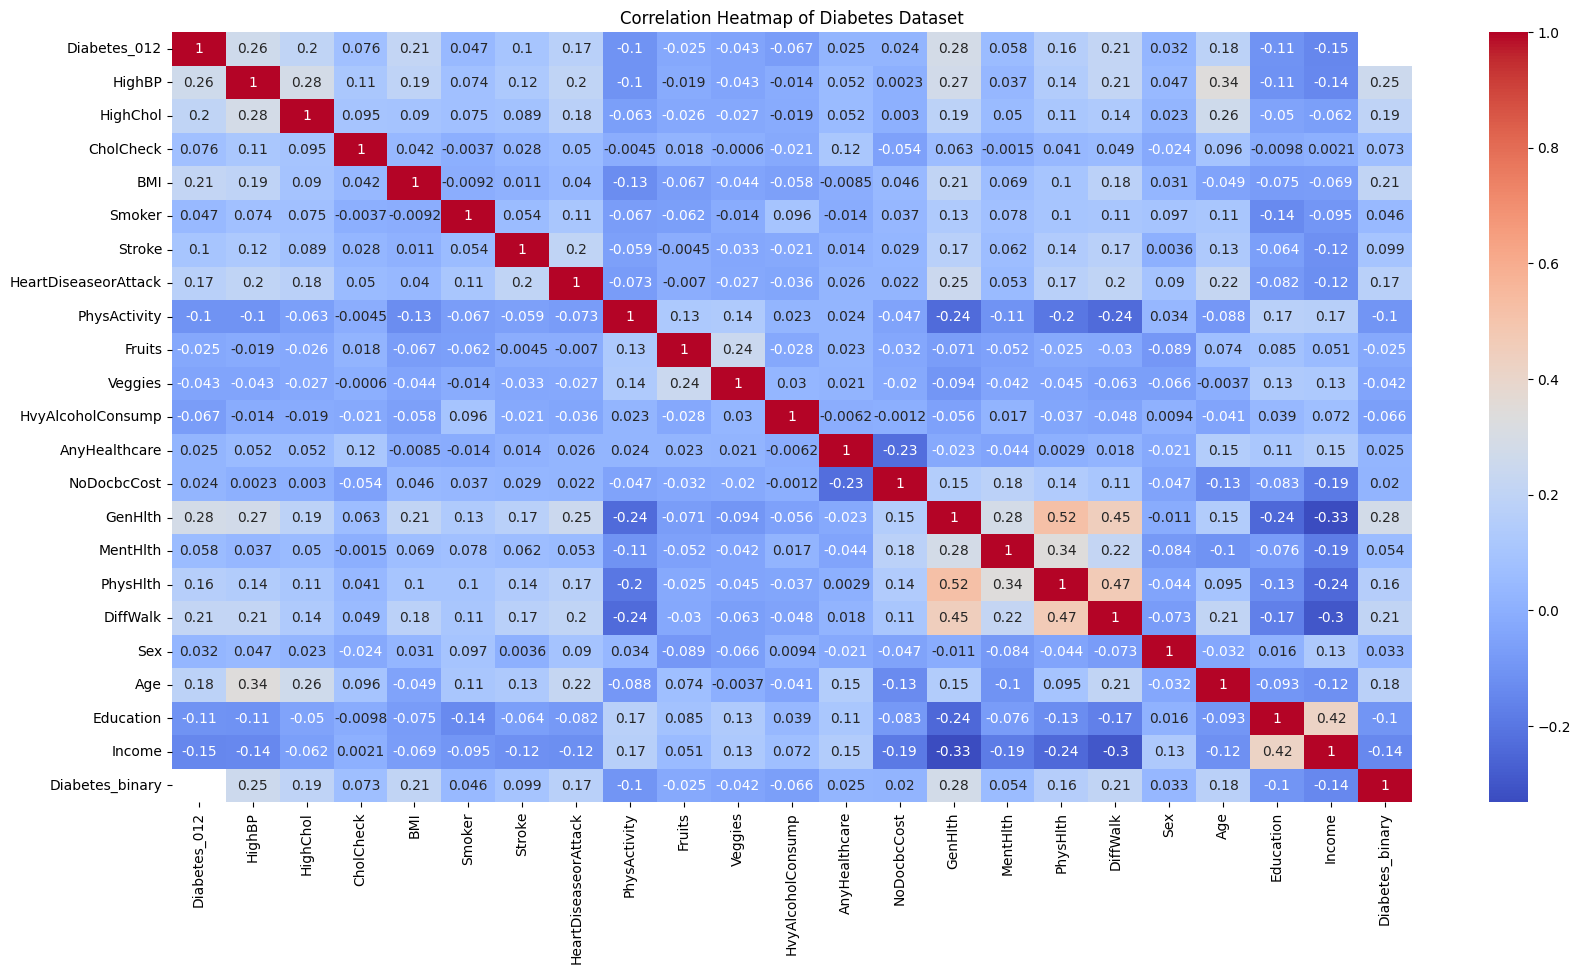

In [ ]:
# Construct a heat map
# Show correlations between features
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()

## **Positive Correlations**

### **ORANGE** (Strongest positive correlations)

* Physical Health with:

1) Difficulty Walking (0.47)

2) General Health (0.52)

* General Health with:

1) Difficulty Walking (0.45)

2) Physical Health (0.52)

* Difficulty Walking with:

1) Physical Health (0.47)

2) General Health (0.45)

* Education with:

1) Income (0.42)

### **PEACH** (Strong positive correlations)

* Mental Health with:  

1) Physical Health (0.34)

2) General Health (0.28)

* High Blood Pressure with:

1) Age (0.34)



---



# **Preprocessing and Feature Selection**

In [ ]:
# StandardScaler is much better for clustering when features have normal or wide distributions

# Select all numerical columns (health indicators)
numerical_cols = data_cleaned.select_dtypes(include=['float64']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the data
scaled_data = scaler.fit_transform(data_cleaned[numerical_cols])

# Every feature is now standardized (centered around 0 and scaled)
# This is important for clustering because K-Means uses distances to group points
print(f"Scaled data shape (Patients, health features): {scaled_data.shape}")

Scaled data shape (Patients, health features): (459255, 21)


### **PCA**

Goal is to reduce the number of features while preserving most of the variance.

PCA-reduced shape: (459255, 17)


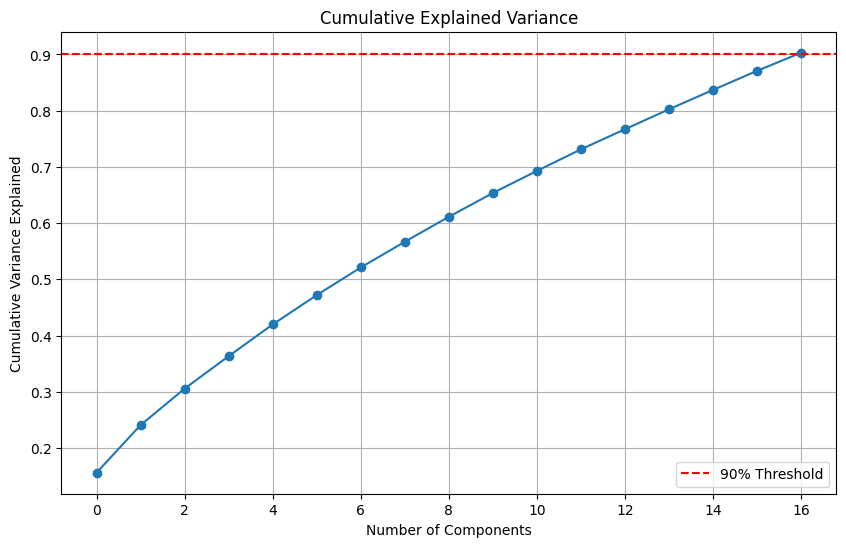

In [ ]:
# Data Visualization using PCA and a scatterplot
# PCA reduces the 21 features to 2-dimensions

# Reduce dimensions to explain ~90% of variance
pca = PCA(n_components=0.90, svd_solver='full')
pca_data = pca.fit_transform(scaled_data)

print("PCA-reduced shape:", pca_data.shape)

# Plot explained variance
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.show()



---



### **Clustering with KMeans and DBSCAN on the PCA-transformed data**

Goal is to partition observations into 'k' clusters that minimize within-cluster variance.

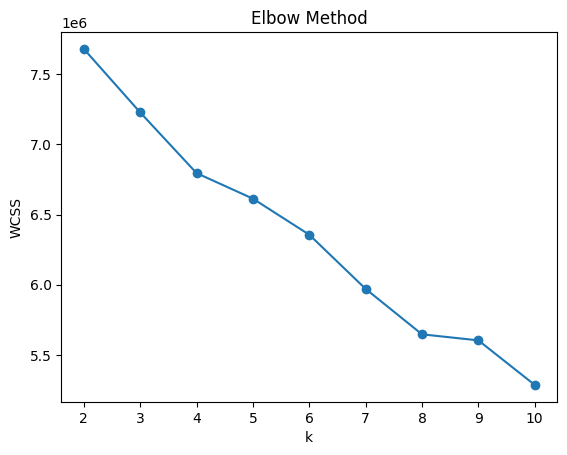

Silhouette Score (k=3, sample of 10000): 0.0801


In [ ]:
# First code I tried was WAY TOO SLOW
# Elbow (fast)
wcss = []
k_range = range(2,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

# Pick k
final_k = 3 # Tried k=2 and got a Silhouette score of 0.1926
kmeans = KMeans(n_clusters=final_k, random_state=42)
labels = kmeans.fit_predict(pca_data)

# Subsample for silhouette
sample_size = 10000
rng = np.random.RandomState(42)
indices = rng.choice(pca_data.shape[0], size=sample_size, replace=False)

silhouette_sample = silhouette_score(
    pca_data[indices],
    labels[indices]
)

print(f"Silhouette Score (k={final_k}, sample of {sample_size}): {silhouette_sample:.4f}")

### Silhouette Score

| Score Range	| Interpretation |
|-------------|:---------------|
| +0.7 to +1.0|	Strong clusters (well separated) ✅ |
| +0.5 to +0.7|	Reasonable clusters ✅ |
| +0.2 to +0.5|	Weak clusters (overlapping) ⚠️ |
| Near 0 or Negative	| Bad clustering ❌ |

 The Silhouette Score on the KMeans PCA-transformed data is 0.1926.

 The underlying issue appears to be with the unbalanced clustering in each K-Means cluster (in other words, the clusters are not very tight or well-separated).

**Observation at the end:**

This is actually a great insight:

Your data doesn’t naturally break into strongly separated clusters based on these variables.

This can be a valid and important conclusion for your unsupervised project:

Many health conditions result from continuous gradients, not hard categories.

KMeans (which assumes spherical clusters) may not be the best fit.

In [ ]:
# Final KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(pca_data)

# Add to DataFrame
data_cleaned['KMeans_Cluster'] = kmeans_labels

# Cluster counts
print(data_cleaned['KMeans_Cluster'].value_counts())

# Silhouette score: Subsample for silhouette score
sample_size = 10000
rng = np.random.RandomState(42)
indices = rng.choice(pca_data.shape[0], size=sample_size, replace=False)

silhouette_sample = silhouette_score(
    pca_data[indices],
    kmeans_labels[indices]
)

print(f"Silhouette Score (k=2, sample of {sample_size}): {silhouette_sample:.4f}")

cluster_profiles = data_cleaned.groupby('KMeans_Cluster').mean()
print(cluster_profiles)

KMeans_Cluster
0    338428
1    120827
Name: count, dtype: int64
Silhouette Score (k=2, sample of 10000): 0.1926
                  HighBP  HighChol  CholCheck        BMI    Smoker    Stroke  \
KMeans_Cluster                                                                 
0               0.357210  0.372646   0.952114  27.851221  0.414138  0.012511   
1               0.726593  0.635115   0.980220  31.026393  0.610236  0.135185   

                HeartDiseaseorAttack  PhysActivity    Fruits   Veggies  ...  \
KMeans_Cluster                                                          ...   
0                           0.041622      0.821634  0.637580  0.828758  ...   
1                           0.275965      0.485496  0.543471  0.699306  ...   

                AnyHealthcare  NoDocbcCost   GenHlth  MentHlth   PhysHlth  \
KMeans_Cluster                                                              
0                    0.950477     0.060305  2.211321  1.996434   1.516000   
1                 

The Silhouette Score is very low (indicative of a weak cluster) but this is common in real-world healthcare datasets.

This tells me that the data is not sharply clustered into two neat groups.

I will try DBScan to find free-form clusters and separate noise.

### **DBSCAN**

Goal for DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is to identitify clusters of arbitrary shape based on density and noise points.

In [ ]:
# The first code took too long; new DBSCN subsample code below

# Subsample for k-distance estimation
sample_size = 10000  # or smaller if needed
rng = np.random.RandomState(42)
indices = rng.choice(pca_data.shape[0], size=sample_size, replace=False)

# DBSCAN on subset
dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(pca_data[indices])

# Create a small DataFrame to examine clusters
dbscan_sample_df = pd.DataFrame(pca_data[indices], columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])
dbscan_sample_df['DBSCAN_Cluster'] = dbscan_labels

# Print counts
print(dbscan_sample_df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 1     6807
 0      648
-1      619
 3      515
 5      404
 8      224
 4      219
 7      187
 9       96
 11      95
 6       34
 14      28
 15      21
 10      19
 12      15
 18      13
 19       9
 17       8
 20       7
 16       7
 23       6
 2        5
 21       5
 22       5
 13       4
Name: count, dtype: int64


Results from DBSCAN:

DBSCAN found 24 cluters. Identified 619 points as "noise" (-1). CLuster 1 is the largerest. The smaller clusters represent rare patterns in the data.

This data has local density pockets but no big monolithic structure.

In [ ]:
# Subset the original scaled data to the indices you sampled
scaled_subset = scaled_data[indices]

# Create a DataFrame for profiling
dbscan_profiles_df = pd.DataFrame(
    scaled_subset,
    columns=numerical_cols
)
dbscan_profiles_df["DBSCAN_Cluster"] = dbscan_labels

# Compute mean feature value per cluster
dbscan_cluster_profiles = dbscan_profiles_df.groupby("DBSCAN_Cluster").mean()
print(dbscan_cluster_profiles)

                  HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
DBSCAN_Cluster                                                                
-1              0.274914  0.164572  -0.638761  0.482909  0.277593  1.017560   
 0              0.578193  0.530714   0.205427  0.073228  0.310009 -0.216530   
 1             -0.092069 -0.057289   0.205427 -0.022327 -0.085179 -0.216530   
 2              1.095783  1.124268   0.205427  0.046173  0.670115 -0.216530   
 3             -0.124839 -0.095704   0.205427  0.126558 -0.065596 -0.216530   
 4             -0.344009 -0.291783   0.205427 -0.037916 -0.045724 -0.216530   
 5             -0.156964 -0.022165   0.205427 -0.287494  0.162982 -0.216530   
 6             -0.794450 -0.771012  -4.867899 -0.456461  0.422474 -0.216530   
 7              0.601745  0.521225   0.205427 -0.104302  0.084781  4.618292   
 8             -0.652577 -0.520882  -4.867899 -0.297802 -0.092392 -0.216530   
 9             -0.305893 -0.281151   0.205427 -0.076

### **Profile Multiple Clusters**

Group and aggregate to compare clusters (-1, 0, 1) side by side.

In [ ]:
# Mean per cluster for selected clusters (e.g., 0, 1, -1)
selected_clusters = dbscan_profiles_df[
    dbscan_profiles_df["Cluster"].isin([0, 1, -1])
]

cluster_profiles = selected_clusters.groupby("Cluster").mean()
print(cluster_profiles)

           HighBP  HighChol  CholCheck       BMI    Smoker   Stroke  \
Cluster                                                               
-1       0.274914  0.164572  -0.638761  0.482909  0.277593  1.01756   
 0       0.578193  0.530714   0.205427  0.073228  0.310009 -0.21653   
 1      -0.092069 -0.057289   0.205427 -0.022327 -0.085179 -0.21653   

         HeartDiseaseorAttack  PhysActivity    Fruits   Veggies  ...  \
Cluster                                                          ...   
-1                   0.743588     -0.510818 -0.302921 -0.571616  ...   
 0                   2.946658     -0.178339 -0.051032 -0.015151  ...   
 1                  -0.339367      0.029933  0.011922  0.013994  ...   

         AnyHealthcare  NoDocbcCost   GenHlth  MentHlth  PhysHlth  DiffWalk  \
Cluster                                                                       
-1           -1.012501     1.194005  0.935606  1.194051  0.965373  0.727530   
 0            0.238819    -0.319957  0.587297 

### **Visualize Clusters**



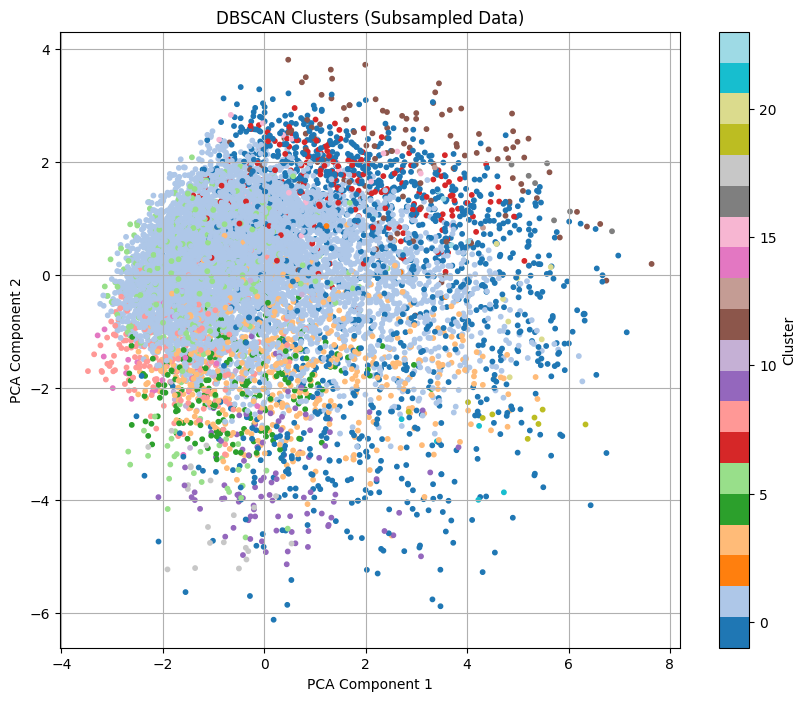

In [ ]:
# Visualize the clusters
plt.figure(figsize=(10,8))
plt.scatter(
    pca_data[indices,0],
    pca_data[indices,1],
    c=dbscan_labels,
    cmap="tab20",
    s=10
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clusters (Subsampled Data)")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

Results of plot:

The colors show the different DBSCAN clusters. Dense areas of the plot correspond to the biggest clusters I saw in '.value_counts()'.

The results are expected: One or two big clusters (the "cloud" in the center). Many tiny clusters on the edges. Noise points on the very outskirts of the plot.

In [ ]:
# Cross-tab clusters with diabetes prevalence
# Check to see if some clusters have more diabetes cases

# Subsample diabetes labels
diabetes_subset = data.iloc[indices]['Diabetes_binary'].values

# Cross-tab clusters vs. diabetes
df_ct = pd.DataFrame({
    'Cluster': dbscan_labels,
    'Diabetes': diabetes_subset
})

cross_tab = pd.crosstab(df_ct['Cluster'], df_ct['Diabetes'])
print(cross_tab)

Diabetes   0.0  1.0
Cluster            
-1         231  100
 0         219  118
 1        2915  470
 3         209   34
 4          91   10
 5         169    9
 6          20    0
 7          78   28
 8         120    0
 9          46    6
 10          3    1
 11         35   17
 12          6    6
 13          0    1
 14         13    0
 15         11    2
 16          1    3
 17          2    0
 18          7    0
 19          2    1
 20          2    2
 21          4    1
 22          2    1
 23          1    2


Results:

Cluster 0 has 118 diabetic cases among 337 people (~35%). Cluster 0 may be a higher-rish group than initially thought.

Next step:

Subset the scaled data and isolate the rows in the cluster. Compute the '.mean()' for each column.

In [ ]:
# Subsample the original scaled data to your sample indices
scaled_subset = scaled_data[indices]

# Create a DataFrame for profiling
dbscan_profiles_df = pd.DataFrame(
    scaled_subset,
    columns=numerical_cols
)
dbscan_profiles_df["Cluster"] = dbscan_labels

# Select Cluster 0
cluster0_data = dbscan_profiles_df[dbscan_profiles_df["Cluster"] == 0]

# Compute mean feature values for Cluster 0
cluster0_profile = cluster0_data.mean()
print("Cluster 0 profile (standardized):")
print(cluster0_profile)

Cluster 0 profile (standardized):
HighBP                  0.578193
HighChol                0.530714
CholCheck               0.205427
BMI                     0.073228
Smoker                  0.310009
Stroke                 -0.216530
HeartDiseaseorAttack    2.946658
PhysActivity           -0.178339
Fruits                 -0.051032
Veggies                -0.015151
HvyAlcoholConsump      -0.254322
AnyHealthcare           0.238819
NoDocbcCost            -0.319957
GenHlth                 0.587297
MentHlth               -0.028589
PhysHlth                0.398313
DiffWalk                0.487057
Sex                     0.355807
Age                     0.733861
Education              -0.189828
Income                 -0.227421
Cluster                 0.000000
dtype: float64


**Results:**

For all people in cluster 0, the results show the average z-score per feature. Positive means above-average, negtive means below-average.

1) HeartDiseaseorAttack = +2.95: 🚨 This is extremely high.

* This is ~3 standard deviations above the mean.

* Suggests almost everyone in this cluster reported prior heart disease or heart attack.

2) Age = +0.73:

* Older than average.

3) GenHlth = +0.59:

* Worse general health (note: higher score often means worse health on these scales).

4) HighBP = +0.58:

* More hypertension.

5) HighChol = +0.53:

* More high cholesterol.

6) DiffWalk = +0.49:

* More difficulty walking.

7) PhysHlth = +0.40:

* More physical health problems.

8) Smoker = +0.31:

* Somewhat more smoking.

Interpretation:

This cluster represents older, sicker, higher-cardiovascular-risk individuals, who:

* Have much more heart disease.

* Worse general health.

* More hypertension and cholesterol problems.

BMI was only slightly above average; so surprisingly, weight was not a major driver.



---



# **Conclusion:**

DBSCAN Cluster 0 showed substantially elevated standardized means for heart disease history (+2.95), hypertension (+0.58), and high cholesterol (+0.53), as well as higher age (+0.73) and poorer general health (+0.59). This cluster also had the highest diabetes prevalence in the sample (35%). These results suggest that cardiovascular comorbidity and older age are important risk factors correlating with diabetes in this dataset.